In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [22]:
# Configurando hiperparâmetros.
args = {
    'batch_size': 32,
    'lr': 0.001,
    'num_epochs': 10,
}

# Definindo dispositivo de hardware
if torch.cuda.is_available():
    args['device'] = torch.device('cuda')
else:
    args['device'] = torch.device('cpu')

print(args['device'])

cuda


In [3]:
data_transform = transforms.Compose([
                                     transforms.Resize(224),
                                     transforms.ToTensor(),
                                     transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                          std=[0.229, 0.224, 0.225])
                  ])

train_set = datasets.ImageFolder(root='../data/fer2013/train', transform=data_transform)
test_set = datasets.ImageFolder(root='../data/fer2013/test', transform=data_transform)

In [4]:
print(f"Imagens de treino: {len(train_set)}")
print(f"Classes encontradas: {train_set.class_to_idx}")

Imagens de treino: 28709
Classes encontradas: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.0648367].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.0822659].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6212862..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2914162].
Clippin

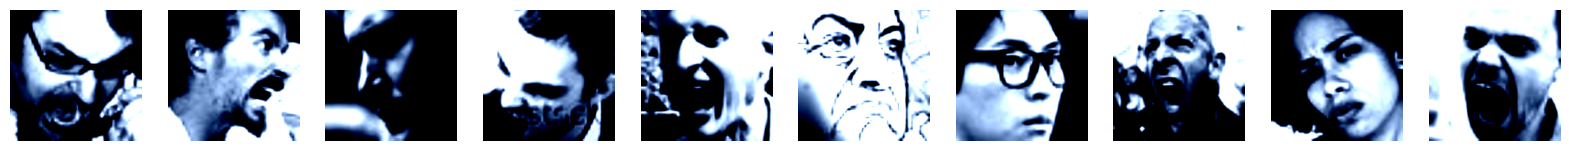

In [5]:
fig, axs = plt.subplots(1,10, figsize=(20, 2))
for i in range(10):
  data, label = test_set[i]
  axs[i].imshow(data.permute((1,2,0)))
  axs[i].axis('off')

In [6]:
train_loader = DataLoader(train_set, 
                          batch_size=args['batch_size'], 
                          shuffle=True)

test_loader = DataLoader(test_set, 
                          batch_size=args['batch_size'], 
                          shuffle=False)

In [13]:
# Pegando apenas um batch de dados
imagens, rotulos = next(iter(train_loader))

print(f"Formato do lote de imagens: {imagens.shape}")
print(f"Formato do lote de rótulos: {rotulos.shape}")
print(f"Primeiro rótulo do lote: {rotulos[0]}")

Formato do lote de imagens: torch.Size([32, 3, 224, 224])
Formato do lote de rótulos: torch.Size([32])
Primeiro rótulo do lote: 5


In [14]:
import torchvision.models as models
import torch.nn as nn

net = models.resnet18(weights='DEFAULT')
print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [18]:
for param in net.parameters():
    param.requires_grad = False

num_features_in = net.fc.in_features
num_features_out = net.fc.out_features
print(num_features_in)
print(num_features_out)

512
7


In [19]:
novo_features_out = 7
net.fc = nn.Linear(num_features_in, novo_features_out)
net = net.to(args['device'])

print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [21]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.fc.parameters(), lr=args['lr'])


In [25]:
from sklearn.metrics import accuracy_score

def train(net, criterion, optimizer, train_loader, device):
    net.train()
    epoch_train_loss = []
    pred_list, rotulo_list = [], []
    
    for dado, rotulo in train_loader:
        dado, rotulo = dado.to(device), rotulo.to(device)
        
        ypred = net(dado)
        loss = criterion(ypred, rotulo)
        epoch_train_loss.append(loss.item())
        
        _, pred = torch.max(ypred, axis=1)
        pred_list.extend(pred.cpu().numpy())
        rotulo_list.extend(rotulo.cpu().numpy())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        

    train_acc = accuracy_score(rotulo_list, pred_list)
    train_loss = np.mean(epoch_train_loss)

    return train_acc, train_loss

In [26]:
def validate(net, criterion, test_loader, device):
    net.eval()
    epoch_test_loss = []
    pred_list, rotulo_list = [], []

    with torch.no_grad():
        for dado, rotulo in test_loader:
            dado, rotulo = dado.to(device), rotulo.to(device)

            ypred = net(dado)
            loss = criterion(ypred, rotulo)
            epoch_test_loss.append(loss.item())
            
            _, pred = torch.max(ypred, axis=1)
            pred_list.extend(pred.cpu().numpy())
            rotulo_list.extend(rotulo.cpu().numpy())

    test_acc = accuracy_score(rotulo_list, pred_list)
    test_loss = np.mean(epoch_test_loss)

    return test_acc, test_loss

In [27]:
import time

all_epoch_train_loss = []
all_epoch_train_acc = []
all_epoch_test_loss = []
all_epoch_test_acc = []

print(f"Iniciando o treinamento por {args['num_epochs']} épocas...\n")

for epoch in range(args['num_epochs']):
    start_time = time.time()

    treino_acc, treino_loss = train(net, criterion,optimizer ,train_loader, args['device'])
    teste_acc, teste_loss = validate(net, criterion, test_loader, args['device'])

    end_time = time.time()
    tempo_total = end_time - start_time

    all_epoch_train_loss.append(treino_loss)
    all_epoch_train_acc.append(treino_acc)
    all_epoch_test_loss.append(teste_loss)
    all_epoch_test_acc.append(teste_acc)

    # Imprimindo o relatório da época na tela
    print(f"Época {epoch+1}/{args['num_epochs']} | Tempo: {tempo_total:.0f}s")
    print(f"Treino - Loss: {treino_loss:.4f} | Acc: {treino_acc*100:.2f}%")
    print(f"Teste  - Loss: {teste_loss:.4f} | Acc: {teste_acc*100:.2f}%\n")

Iniciando o treinamento por 10 épocas...

Época 1/10 | Tempo: 96s
Treino - Loss: 1.6090 | Acc: 37.01%
Teste  - Loss: 1.5633 | Acc: 39.93%

Época 2/10 | Tempo: 66s
Treino - Loss: 1.5052 | Acc: 42.10%
Teste  - Loss: 1.5088 | Acc: 40.72%

Época 3/10 | Tempo: 67s
Treino - Loss: 1.4835 | Acc: 42.85%
Teste  - Loss: 1.4942 | Acc: 43.63%

Época 4/10 | Tempo: 76s
Treino - Loss: 1.4681 | Acc: 43.62%
Teste  - Loss: 1.4825 | Acc: 42.83%

Época 5/10 | Tempo: 85s
Treino - Loss: 1.4637 | Acc: 44.01%
Teste  - Loss: 1.5117 | Acc: 42.39%

Época 6/10 | Tempo: 77s
Treino - Loss: 1.4597 | Acc: 44.01%
Teste  - Loss: 1.4832 | Acc: 42.48%

Época 7/10 | Tempo: 70s
Treino - Loss: 1.4469 | Acc: 44.62%
Teste  - Loss: 1.4770 | Acc: 44.22%

Época 8/10 | Tempo: 69s
Treino - Loss: 1.4495 | Acc: 44.40%
Teste  - Loss: 1.4819 | Acc: 44.46%

Época 9/10 | Tempo: 70s
Treino - Loss: 1.4455 | Acc: 44.21%
Teste  - Loss: 1.4684 | Acc: 43.55%

Época 10/10 | Tempo: 70s
Treino - Loss: 1.4466 | Acc: 44.64%
Teste  - Loss: 1.4977 | 

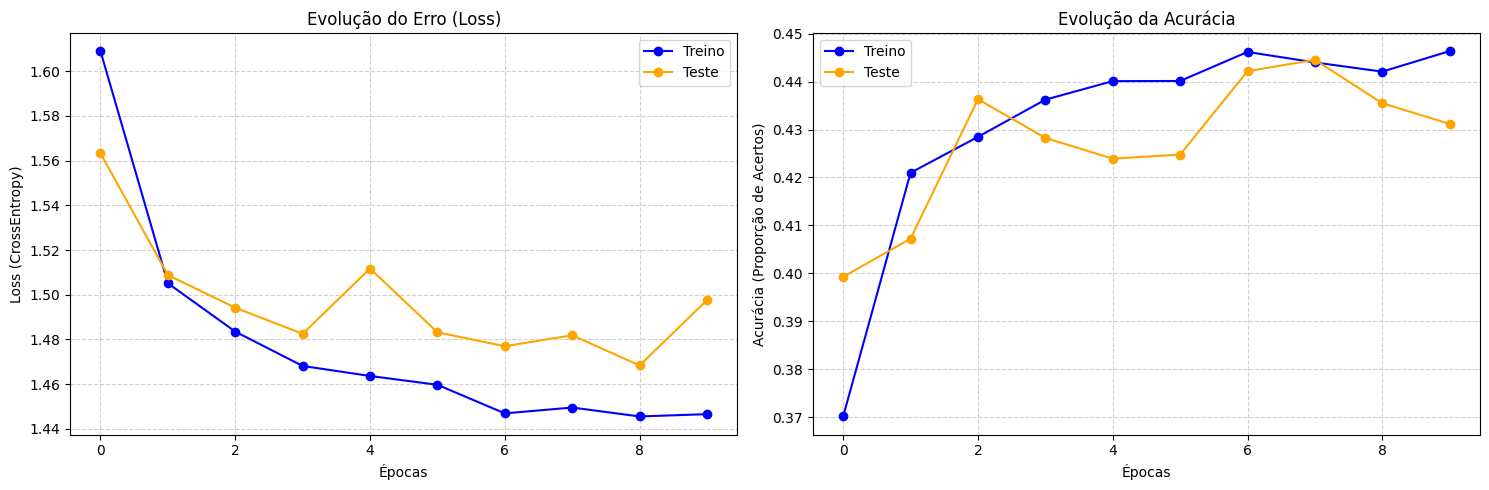

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(all_epoch_train_loss, label='Treino', color='blue', marker='o')
axs[0].plot(all_epoch_test_loss, label='Teste', color='orange', marker='o')

axs[0].set_title('Evolução do Erro (Loss)')
axs[0].set_xlabel('Épocas')
axs[0].set_ylabel('Loss (CrossEntropy)')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

axs[1].plot(all_epoch_train_acc, label='Treino', color='blue', marker='o')
axs[1].plot(all_epoch_test_acc, label='Teste', color='orange', marker='o')

axs[1].set_title('Evolução da Acurácia')
axs[1].set_xlabel('Épocas')
axs[1].set_ylabel('Acurácia (Proporção de Acertos)')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

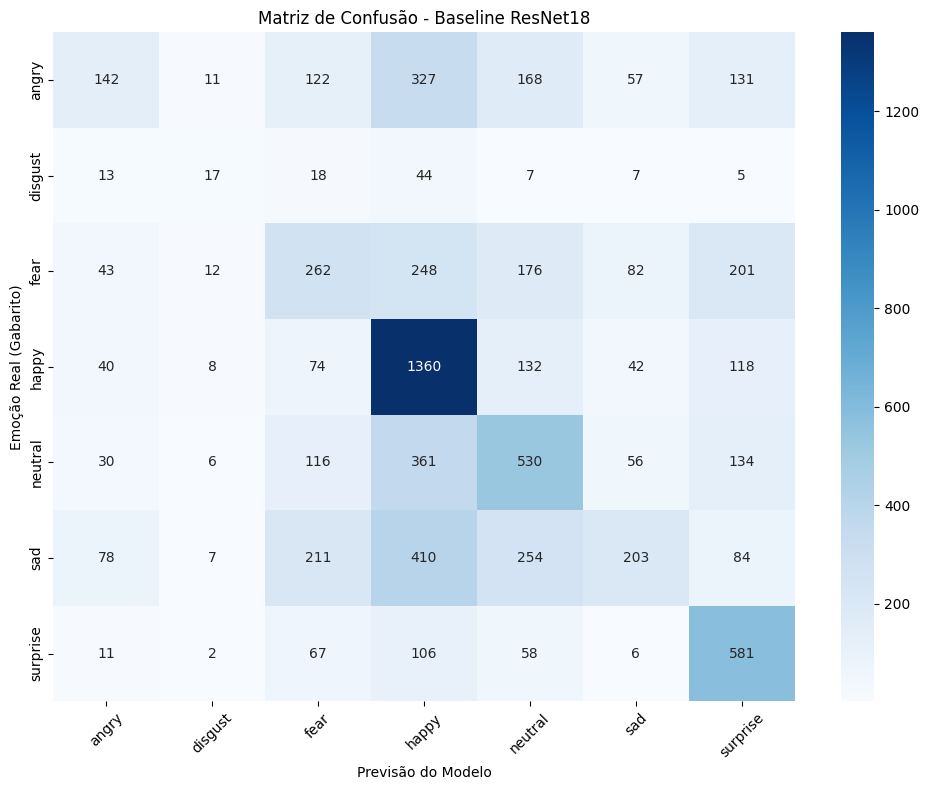

In [29]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

nome_das_classes = train_set.classes 

y_real = []
y_pred = []

net.eval()

with torch.no_grad():
    for dado, rotulo in test_loader:
        dado = dado.to(args['device'])

        saida = net(dado)

        _, previsao = torch.max(saida, axis=1)

        y_pred.extend(previsao.cpu().numpy())
        y_real.extend(rotulo.numpy())


matriz = confusion_matrix(y_real, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(matriz, 
            annot=True,          
            fmt='d',             
            cmap='Blues',       
            xticklabels=nome_das_classes, 
            yticklabels=nome_das_classes)
plt.title('Matriz de Confusão - Baseline ResNet18')
plt.ylabel('Emoção Real (Gabarito)')
plt.xlabel('Previsão do Modelo')

plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

In [30]:
torch.save(net.state_dict(), 'resnet18_baseline_44acc.pth')
print("Pesos do modelo Baseline salvos com sucesso!")

Pesos do modelo Baseline salvos com sucesso!
